In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm  

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.io.image import decode_image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import sys, os
sys.path.append(os.path.abspath('..'))
from CustomDataset import CustomDataset
from EarlyStopping import EarlyStopping

### Data

In [18]:
## TRAIN DATALOADER
train_image_dir = "../../data/mobile detection.v16i.yolov11/train/images"
train_annotation_dir = "../../data/mobile detection.v16i.yolov11/train/labels"
train_annotations = os.listdir(train_annotation_dir)

train_dataset = CustomDataset(train_image_dir, 
                              train_annotations, 
                              train_annotation_dir, 
                              transform=transforms.ToTensor())

train_data_loader = DataLoader(train_dataset, 
                               batch_size=4, 
                               shuffle=True, 
                               collate_fn=lambda x: tuple(zip(*x)))

## VAL DATALOADER
val_image_dir = "../../data/mobile detection.v16i.yolov11/valid/images"
val_annotation_dir = "../../data/mobile detection.v16i.yolov11/valid/labels"
val_annotations = os.listdir(val_annotation_dir)

val_dataset = CustomDataset(val_image_dir, 
                              val_annotations, 
                              val_annotation_dir, 
                              transform=transforms.ToTensor())

val_data_loader = DataLoader(val_dataset, 
                               batch_size=4, 
                               shuffle=False, 
                               collate_fn=lambda x: tuple(zip(*x)))



## Load pretrain FasterRcnn model
I am using [pytorch's FasterRCNN Resnet50](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn.html) architecture. It combines Faster R-CNN with ResNet-50 backbone and Feature Pyramid Network (FPN)

In [19]:
num_classes = 4 

## get the pretrained backbone model
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(
    weights=weights,
    progress=True,
    trainable_backbone_layers = 1
    )

print(model)

# Replace the classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)


# for param in model.backbone.parameters():
#     param.requires_grad = False


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

## Look at 2 training sample
Visualize training sample and check if the data loader is working correctly

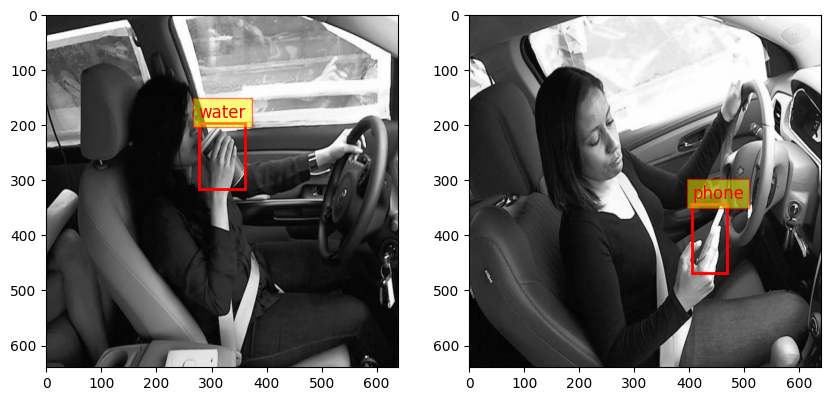

In [20]:
# Create the plot
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax = ax.ravel()

# Get a batch of images and targets from the data loader
data_loader_iter = iter(train_data_loader)
images, targets = next(data_loader_iter)


class_names = ['background', 'water', 'food', 'phone', 'smoking']

# Plot the images with bounding boxes
for idx in range(2):
    image = images[idx].permute(1, 2, 0).numpy()  # Convert from (C, H, W) to (H, W, C) for visualization
    target = targets[idx]
    boxes = target["boxes"].numpy()
    labels = target["labels"].numpy()

    ax[idx].imshow(image)

    # Add bounding boxes to the image
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin
        rect = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax[idx].add_patch(rect)
        ax[idx].text(
            xmin,
            ymin - 10,
            f"{class_names[label]}",
            color="red",
            fontsize=12,
            bbox=dict(facecolor="yellow", alpha=0.5, edgecolor="red"),
        )

# Display the image with bounding boxes
plt.show()

In [ ]:
# Step 5: Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
print("trainable:" , len(params))
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
num_epochs = 1
# Initialize metric
metric = MeanAveragePrecision().to(device)
early_stopper = EarlyStopping(patience=7, min_delta=1e-4, mode="max")


trainable: 80


In [ ]:



# Storage for history
history = {
    "train_loss": [],
    "val_map": [],
    "val_map_50": [],
    "loss_classifier": [],
    "loss_box_reg": []
}

def to_device(obj, device=device):
    if torch.is_tensor(obj):
        return obj.to(device)
    if isinstance(obj, (list, tuple)):
        return [to_device(x, device) for x in obj]
    if isinstance(obj, dict):
        return {k: to_device(v, device) for k, v in obj.items()}
    return obj

# --- Start Training Loop ---
for epoch in range(num_epochs):
    
    # --- TRAINING PHASE ---
    model.train()
    
    # Initialize accumulators for this epoch
    running_loss = 0.0
    running_cls_loss = 0.0
    running_box_loss = 0.0
    
    # Create progress bar for training
    train_loop = tqdm(enumerate(train_data_loader), total=len(train_data_loader), leave=True)
    train_loop.set_description(f"Epoch {epoch+1}/{num_epochs} [Train]")

    for i, (images, targets) in train_loop:
        images = to_device(images)
        targets = to_device(targets)

        # Fix 1D boxes if necessary
        for t in targets:
            if t["boxes"].ndim == 1: 
                t["boxes"] = t["boxes"].view(-1, 4)

        # Forward pass
        loss_dict = model(images, targets)
        
        # Calculate total loss
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # --- Tracking Metrics ---
        loss_value = losses.item()
        running_loss += loss_value
        
        # Track specific losses
        # Check if keys exist to prevent errors if model architecture changes
        cls_loss = loss_dict['loss_classifier'].item() if 'loss_classifier' in loss_dict else 0
        box_loss = loss_dict['loss_box_reg'].item() if 'loss_box_reg' in loss_dict else 0
        
        running_cls_loss += cls_loss
        running_box_loss += box_loss

        # Update progress bar with current batch loss
        train_loop.set_postfix(loss=loss_value, cls=cls_loss, box=box_loss)

    # Step LR Scheduler
    if scheduler:
        scheduler.step()

    # Calculate average losses for the epoch
    avg_train_loss = running_loss / len(train_data_loader)
    avg_cls_loss = running_cls_loss / len(train_data_loader)
    avg_box_loss = running_box_loss / len(train_data_loader)

    # Store in history
    history["train_loss"].append(avg_train_loss)
    history["loss_classifier"].append(avg_cls_loss)
    history["loss_box_reg"].append(avg_box_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    metric.reset()
    
    # Create progress bar for validation
    val_loop = tqdm(enumerate(val_data_loader), total=len(val_data_loader), leave=True)
    val_loop.set_description(f"Epoch {epoch+1}/{num_epochs} [Valid]")

    with torch.no_grad():
        for i, (vinputs, vlabels) in val_loop:
            # Move data to device
            vinputs = to_device(vinputs)
            vlabels = to_device(vlabels)

            # Get predictions
            voutputs = model(vinputs)
            
            # Update metric
            metric.update(voutputs, vlabels)

    # Compute Metrics
    metric_results = metric.compute()
    val_map = metric_results['map'].item()
    val_map_50 = metric_results['map_50'].item()
    
    history["val_map"].append(val_map)
    history["val_map_50"].append(val_map_50)

    # EARLY STOPPING CHECK
    if early_stopper.step(val_map_50, model, epoch):
        print(f"Early stopping triggered at epoch {epoch+1}. Best epoch: {early_stopper.best_epoch+1} "
              f"with val mAP={early_stopper.best:.4f}")
        break

    # --- FINAL EPOCH LOGGING ---
    print(f"\nSummary Epoch {epoch+1}:")
    print(f"Train Loss: {avg_train_loss:.4f} | Cls Loss: {avg_cls_loss:.4f} | Box Reg: {avg_box_loss:.4f}")
    print(f"Val mAP:    {val_map:.4f}       | Val mAP50: {val_map_50:.4f}")
    print("-" * 60)

Epoch 1/100 [Train]:   4%|▍         | 280/7285 [44:42<18:38:26,  9.58s/it, box=0.133, cls=0.103, loss=0.247]  


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "fasterRCNN.pth")

{'boxes': tensor([[292.4398, 168.4269, 371.1377, 274.5986]], device='cuda:0'), 'labels': tensor([1], device='cuda:0'), 'scores': tensor([0.9992], device='cuda:0')}
{'boxes': tensor([[213.2398, 250.5361, 293.1463, 418.4839]], device='cuda:0'), 'labels': tensor([1], device='cuda:0'), 'scores': tensor([0.9996], device='cuda:0')}
{'boxes': tensor([[194.4989, 293.9310, 262.1494, 421.8537]], device='cuda:0'), 'labels': tensor([4], device='cuda:0'), 'scores': tensor([0.9991], device='cuda:0')}
{'boxes': tensor([[203.4257, 285.8968, 287.8956, 385.0819]], device='cuda:0'), 'labels': tensor([2], device='cuda:0'), 'scores': tensor([0.9972], device='cuda:0')}
{'boxes': tensor([[215.1284, 291.4091, 260.1248, 354.0296]], device='cuda:0'), 'labels': tensor([4], device='cuda:0'), 'scores': tensor([0.9986], device='cuda:0')}
{'boxes': tensor([[266.7605, 195.9901, 358.0898, 310.5024]], device='cuda:0'), 'labels': tensor([1], device='cuda:0'), 'scores': tensor([0.9991], device='cuda:0')}
{'boxes': tensor

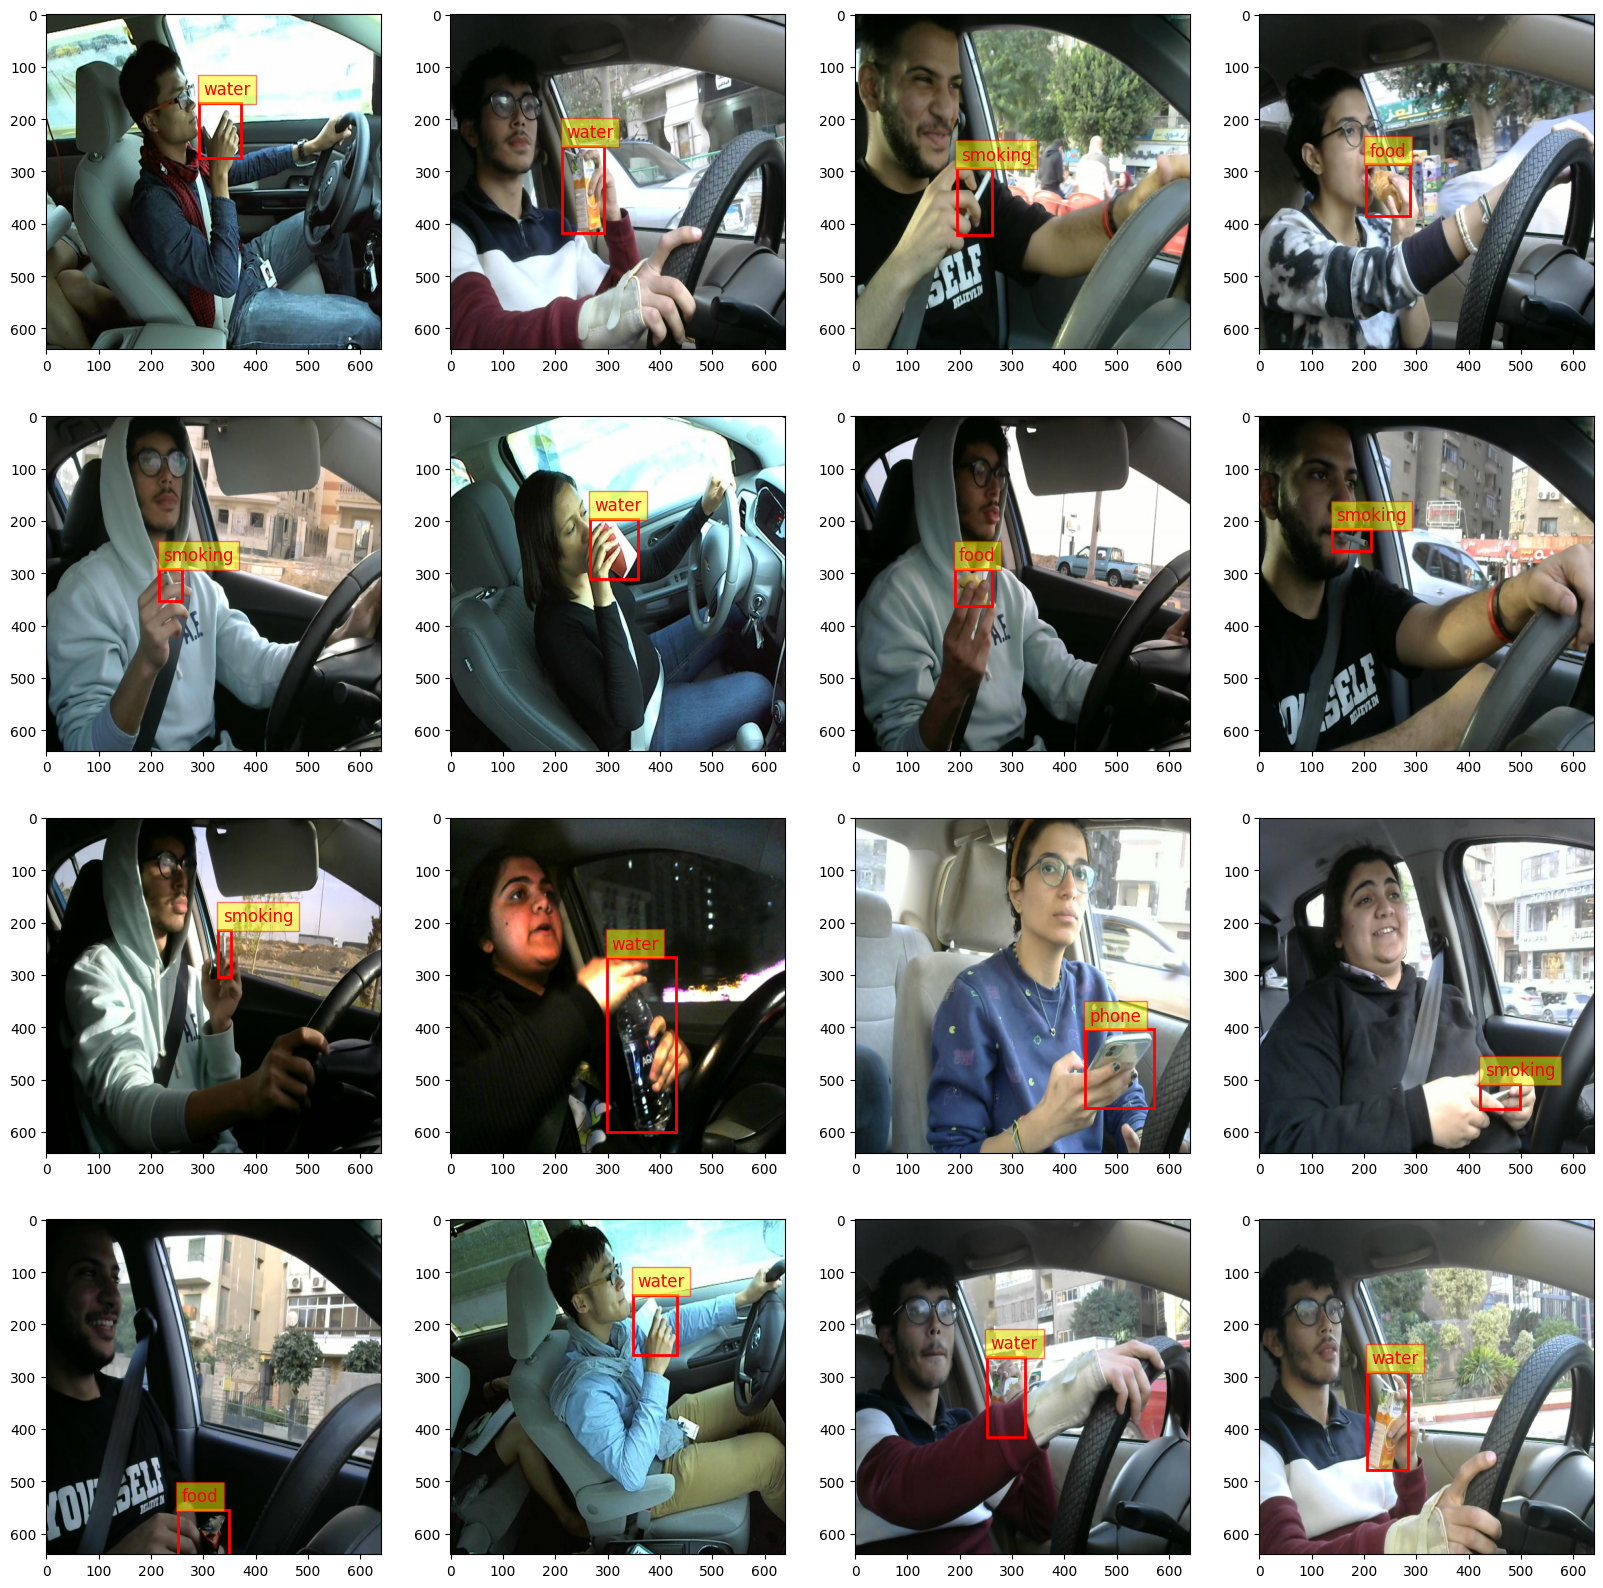

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image,ImageDraw
import random
import os
import torch
import torchvision
from torchvision.transforms import transforms


# # Step 1: Recreate the model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # Step 3: Load Pretrained Model and Modify for Custom Classes
num_classes = 4  
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)
# # Replace the classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)

model.load_state_dict(torch.load("fasterRCNN.pth"))
# Assuming `model` and `test_data_loader` are already defined
model.eval()  # Set the model to evaluation mode
model.to(device)  # Ensure the model is on the correct device

# Create the plot
fig, ax = plt.subplots(4, 4, figsize=(20,20))
ax = ax.ravel()

transform = transforms.ToTensor()

test_dir = "../data/mobile detection.v7i.yolov11/test/images"
test_list_file = os.listdir(test_dir)
# font = ImageFont.truetype("arial.ttf", 28)


class_names = ['background', 'water', 'food', 'phone', 'smoking']

for idx in range(16):
    # Prepare the image
    img_path = os.path.join(test_dir,random.choice(test_list_file))
    image = Image.open(img_path)
    image = transform(image)
    image_tensor = image.unsqueeze(0).to(device)  # Add a batch dimension

    # Get predictions
    with torch.no_grad():
        prediction = model(image_tensor)[0]  # Get the first image's predictions

    print(prediction)

    # Convert image to numpy for visualization
    image_np = image.cpu().permute(1, 2, 0).numpy()  # Convert (C, H, W) -> (H, W, C)

    # Extract predictions
    boxes = prediction["boxes"].cpu().numpy()
    labels = prediction["labels"].cpu().numpy()
    scores = prediction["scores"].cpu().numpy()

    ax[idx].imshow(image_np)

    img = Image.open(img_path)
    colors = [(255,0,0),(0,255,0),(0,0,255),(255,0,255),(255,255,0),(0,255,255),(255,140,0),(0,128,0)]

    # Add bounding boxes to the image
    for box, label, score in zip(boxes, labels, scores):
        if score >= 0.8:
            xmin, ymin, xmax, ymax = box
            width, height = xmax - xmin, ymax - ymin
            rect = patches.Rectangle(
                (xmin, ymin),
                width,
                height,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax[idx].add_patch(rect)
            ax[idx].text(
                xmin + 8,
                ymin - 16,
                f"{class_names[label]}",
                color="red",
                fontsize=12,
                bbox=dict(facecolor="yellow", alpha=0.5, edgecolor="red"),
            )
            color = random.choice(colors)
            img1 = ImageDraw.Draw(img)
            img1.rectangle([(int(xmin),int(ymin)),(int(xmax),int(ymax))],outline=color,width=4)
            img1.text((int(xmin),int(ymin-30)), "Bear", fill=color)
            # img.save(f'img/image_{idx}.png')


# Display the image with bounding boxes
plt.show()